# Optimization for AI Project - Deiana

For this project, we will explore and try to design a GA algorithm to automatically synthesize FIR filters according to a desired frequency response. We will start with a baseline simplified proof of concept, and then we will take inspiration from a couple of papers to produce more useful and realistic results.

A digital FIR filter is characterized by the following transfer function: $H(s)=\sum^{N}_{n=0}a_nz^{-n}$, where $N$ is the order of the filter, and $a_n$ are
defined as the filter coefficients.

As we can see, an individual in this case is simply a finite vector of real values, which allows us to inherit all the literature about real-valued GAs. In reality,
digital FIR filters are designed to be implemented in hardware. This presents us with a couple of challenges, namely that hardware costs increase with the order of the filter and the way it's implemented.
As we will later see, a particular ternary encoding called CSD is preferred, as it allows to automatically synthesize a filter from the provided genome and saves up on circuit complexity.
 This, in turn, means that the real-valued GAs, which are quite simple to implement in software, are not desirable for real-world FIR filter design. Nonetheless, precisely because of its simplicity,
 we will first implement a real-valued version of the GA as a baseline, and compare it wrt. execution speed, convergence speed, and fitness with the algorithms proposed in the papers.

## Real-valued GA baseline

Before we implement the techniques proposed in the papers, it could be interesting to create a simple proof of concept at a higher level. We will implement the classic GA structure, and encode the individuals as simple vectors of real numbers. This will allow us to reuse much of the code when implementing the papers.

The GA will be implemented as follows:
- Chromosome: $x=(x_1,…,x_n)$, where $x_i \in [-1, 1] \subset \mathbb{R}, \forall i \in {0, ..., n}$
- Init: Uniform sampling
- Mutation: Gaussian
- Crossover: Two-point crossover, Discrete recombination
- Selection: Roulette Wheel, Tournament
- Fitness: Minimax, LMS, MSE
- Elitism: 5% of the population [OPTIONAL]

We will use the signal library from Scipy for calculating the frequency response of each individual, together with numpy. For everything else, standard python is enough to implement the GA.

### Implementation

In [70]:
import random, bisect
from itertools import count

import numpy as np
from scipy.signal import freqz

In [71]:
def sample_individual(order):
    individual = []
    for _ in range(order):
        individual.append(random.choice([random.uniform(-1, 1), 0]))
    return individual

In [72]:
def init_pop(order, n_pop):
    return [sample_individual(order) for _ in range(n_pop)]

In [73]:
def mut(individual, p=0.01):
    mutated = []
    for coeff in individual:
        if random.random() < p:
            mutated.append(coeff + random.gauss(sigma=1 - abs(coeff)))  # We want to remain in the [-1, 1] range
        else:
            mutated.append(coeff)
    return mutated

In [74]:
def twopoint_cross(parent1, parent2):
    indexes = random.sample(range(1, len(parent1) - 1), 2)
    indexes.sort()
    return parent1[:indexes[0]] + parent2[indexes[0]:indexes[1]] + parent1[indexes[1]:]


def recomb_cross(parent1, parent2):
    child = []
    for p, q in zip(parent1, parent2):
        a = random.uniform(0, 1)
        child.append(a * p + (1 - a) * q)
    return child


def cross(parent1, parent2, strategy=twopoint_cross):
    return strategy(parent1, parent2)

In [75]:
def _response_diff(individual, target, mode="complex"):
    w, Hi = freqz(individual)  # Hi : complex array
    Ht = np.array([target(wi) for wi in w], dtype=complex)

    if mode == "complex":
        diff = Ht - Hi

    elif mode == "magnitude":
        diff = np.abs(Ht) - np.abs(Hi)

    elif mode == "phase":
        # unwrap to avoid 2π discontinuities
        ph_t = np.unwrap(np.angle(Ht))
        ph_i = np.unwrap(np.angle(Hi))
        diff = ph_t - ph_i

    else:
        raise ValueError("mode must be 'complex', 'magnitude', or 'phase'")

    return diff


def minimax_error(individual, target, mode="complex"):
    diff = _response_diff(individual, target, mode=mode)
    return np.max(np.abs(diff))


def lms_error(individual, target, mode="complex"):
    diff = _response_diff(individual, target, mode=mode)
    return np.linalg.norm(diff)  # sqrt(sum |diff|^2)


def mse_error(individual, target, mode="complex"):
    diff = _response_diff(individual, target, mode=mode)
    return np.mean(np.abs(diff) ** 2)  # mean(|Δ|^2)


def minimax_fit(individual, target, mode="complex"):
    return -minimax_error(individual, target, mode=mode)


def lms_fit(individual, target, mode="complex"):
    return -lms_error(individual, target, mode=mode)


def mse_fit(individual, target, mode="complex"):
    return -mse_error(individual, target, mode=mode)


In [76]:
def roulette_selection(pop, n_pop, fitness, target, mode):
    # Compute raw fitness values (possibly negative)
    fvals = np.array([fitness(ind, target, mode) for ind in pop], dtype=float)

    # Shift to strictly positive (critical!)
    fvals = fvals - fvals.min() + 1e-12

    # Build cumulative distribution
    cum = np.cumsum(fvals)
    tot = cum[-1]

    newpop = []
    for _ in range(n_pop):
        r = random.random() * tot
        idx = bisect.bisect_left(cum, r)

        # clamp index (avoid floating point overshoot)
        if idx >= len(pop):
            idx = len(pop) - 1

        newpop.append(pop[idx])

    return newpop


def tournament_selection(pop, n_pop, fitness, target, mode, k=3):
    newpop = []
    while len(newpop) < n_pop:
        contestants = random.choices(population=pop, k=k)
        contestants.sort(key=lambda x: fitness(x, target, mode), reverse=True)
        newpop.append(contestants[0])
    return newpop


def selection(pop, n_pop, fitness, target, mode, strategy=roulette_selection):
    return strategy(pop, n_pop, fitness, target, mode)

In [77]:
def GA(n_pop, generations, order, target, fitness, elitism=False, mode="complex"):
    best = []
    elites_n = int(n_pop / 100 * 5) if elitism else 0
    # Population initialization
    pop = init_pop(order, n_pop)
    for _ in range(generations):
        pop.sort(key=lambda x: fitness(x, target, mode), reverse=True)
        elites = pop[:elites_n]
        best.append(pop[0])
        for _ in range(n_pop):
            parent1 = pop[random.randint(0, len(pop) - 1)]
            parent2 = pop[random.randint(0, len(pop) - 1)]
            child = mut(cross(parent1, parent2))
            pop.append(child)
        pop = selection(pop, n_pop - elites_n, fitness, target, mode)
        pop.extend(elites)
    return best

### Testing basic FIR filters
Before doing any side-by-side comparisons, we will see how the GA behaves on very simple filter designs.

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="deep",
    font_scale=1.1
)
COLORS = {
    "minimax": sns.color_palette("deep")[0],
    "lms": sns.color_palette("deep")[2],
    "mse": sns.color_palette("deep")[4],
    "target": sns.color_palette("deep")[3],
}

In [79]:
n_pop = 100
generations = 100
order = 8

In [80]:
modes = ["complex", "magnitude"]
metrics = ["minimax", "lms", "mse"]

In [81]:
# ================================================================
# 2. Helper functions for plotting
# ================================================================
def compute_FR(individual, worN=2048):
    w, H = freqz(individual, worN=worN)
    Ht = np.array([target(wi) for wi in w], dtype=complex)
    return w, H, Ht


def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

#### 0. Ideal all-pass filter

In [82]:
def target(w):
    return 1

In [83]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA(n_pop, generations, order, target, minimax_fit, elitism=False, mode=mode)
    results[(mode, "lms")] = GA(n_pop, generations, order, target, lms_fit, elitism=False, mode=mode)
    results[(mode, "mse")] = GA(n_pop, generations, order, target, mse_fit, elitism=False, mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


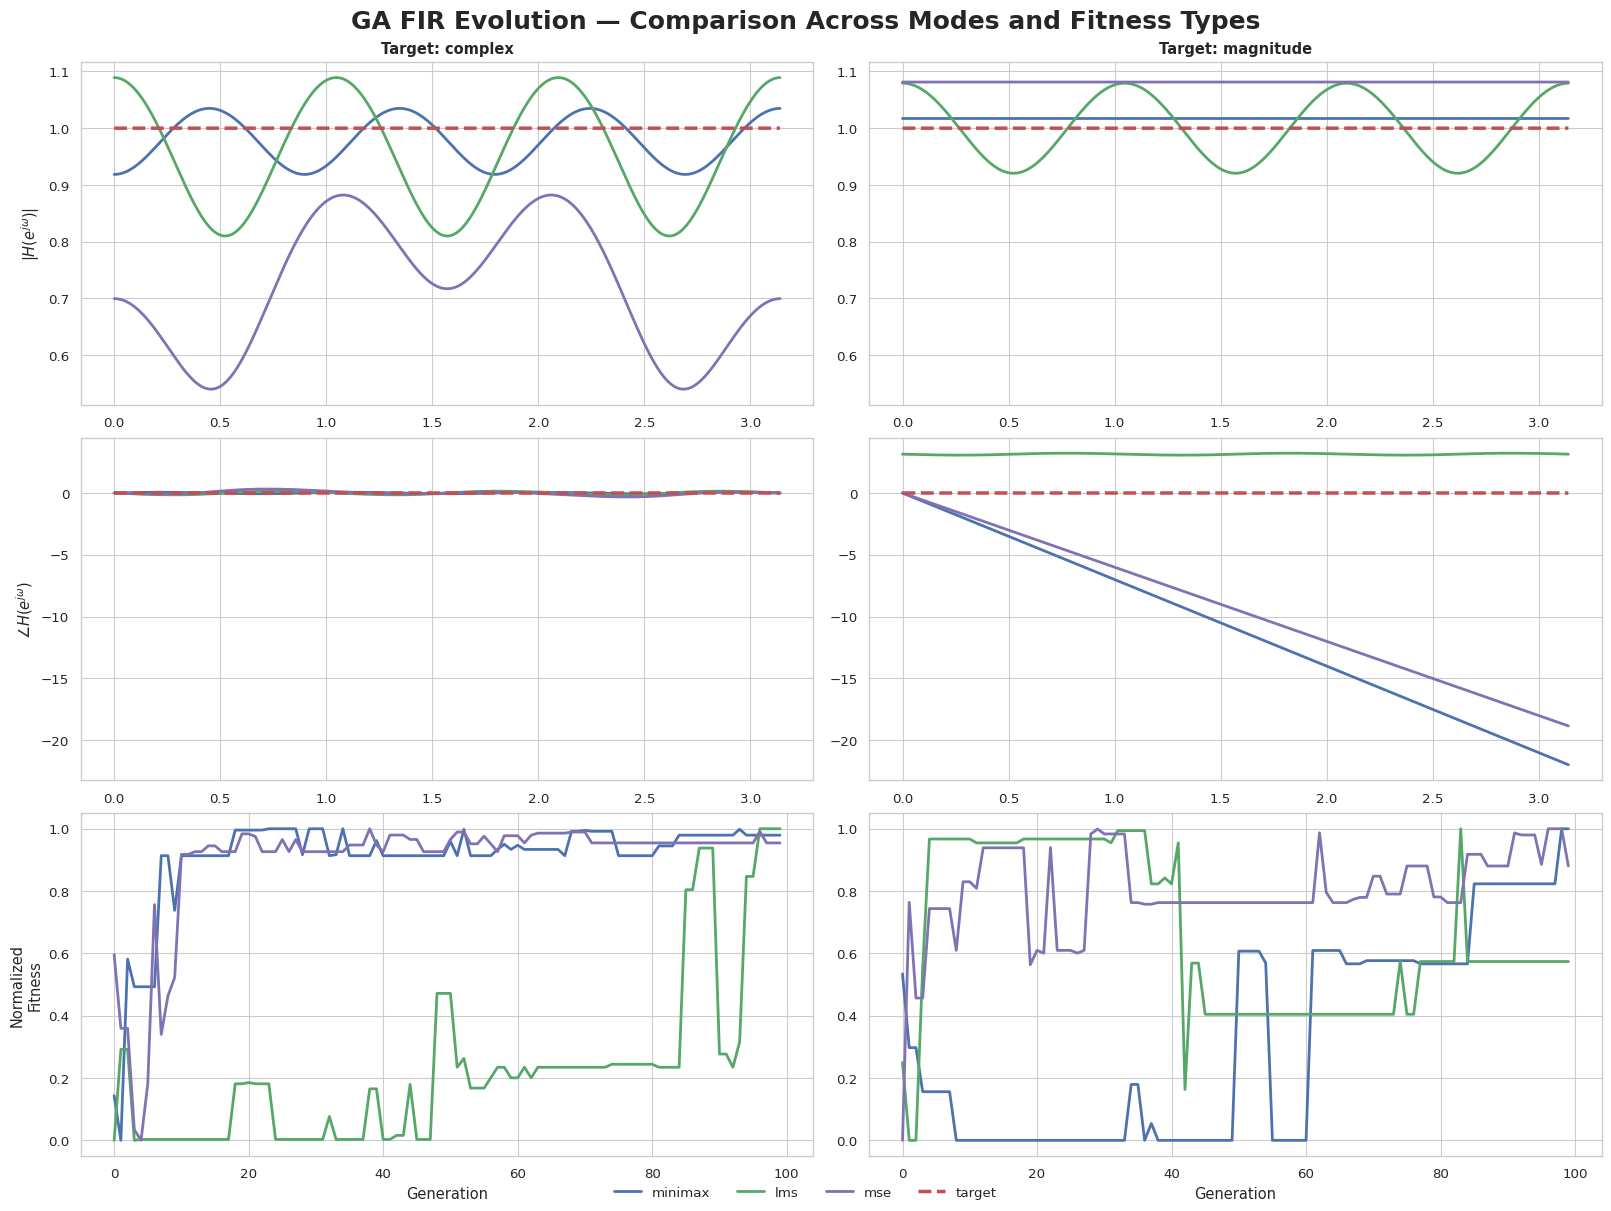

In [84]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]
    b_mse = results[(mode, "mse")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR(b_minimax)
    _, H_lms, _ = compute_FR(b_lms)
    _, H_mse, _ = compute_FR(b_mse)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "mse": np.abs(H_mse),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "mse": np.unwrap(np.angle(H_mse)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit(b, target, mode=mode)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
        "mse": normalize([mse_fit(b, target, mode=mode)
                          for b in results[(mode, "mse")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

#### 1. Ideal high-pass filter

In [85]:
def target(w):
    return 1 if w >= 1.5 else 0

In [86]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA(n_pop, generations, order, target, minimax_fit, elitism=False, mode=mode)
    results[(mode, "lms")] = GA(n_pop, generations, order, target, lms_fit, elitism=False, mode=mode)
    results[(mode, "mse")] = GA(n_pop, generations, order, target, mse_fit, elitism=False, mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


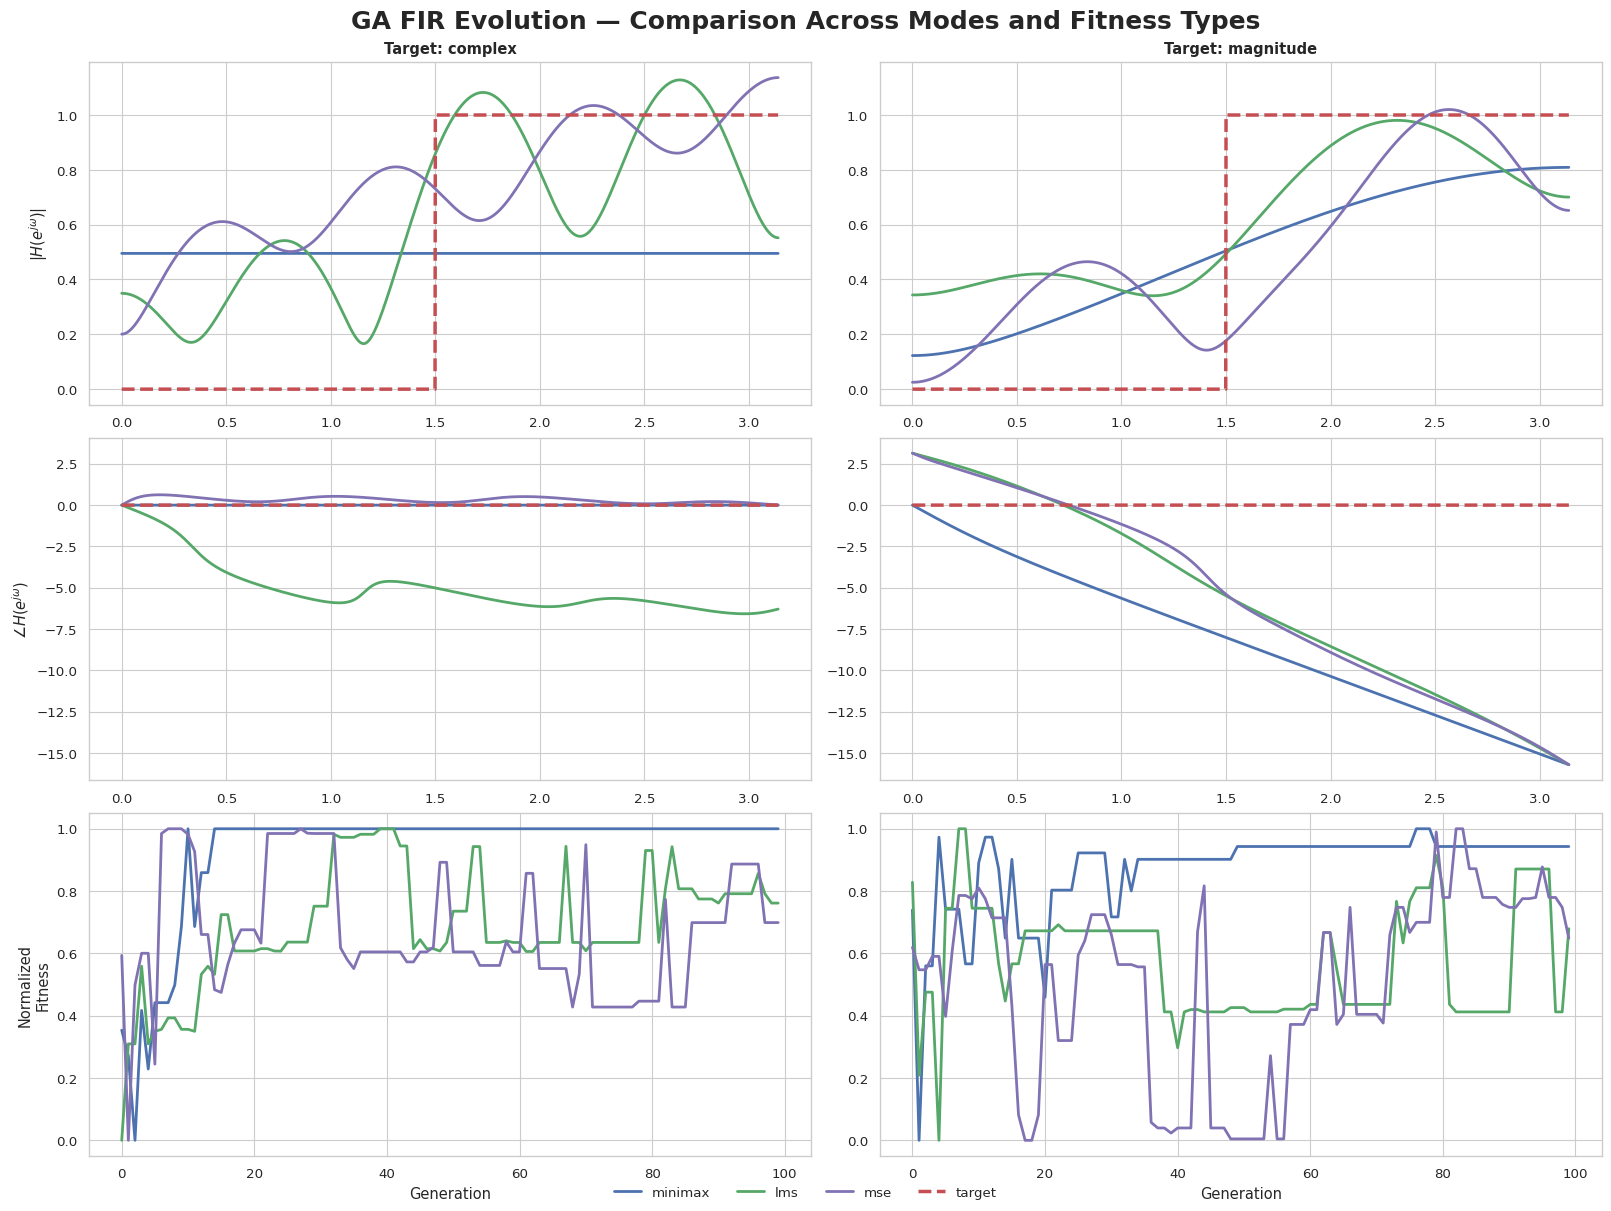

In [87]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]
    b_mse = results[(mode, "mse")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR(b_minimax)
    _, H_lms, _ = compute_FR(b_lms)
    _, H_mse, _ = compute_FR(b_mse)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "mse": np.abs(H_mse),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "mse": np.unwrap(np.angle(H_mse)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit(b, target, mode=mode)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
        "mse": normalize([mse_fit(b, target, mode=mode)
                          for b in results[(mode, "mse")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

#### 2. Ideal band-pass filter

In [88]:
def target(w):
    return 0 if w >= 2 or w <= 1 else 1

In [89]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA(n_pop, generations, order, target, minimax_fit, elitism=False, mode=mode)
    results[(mode, "lms")] = GA(n_pop, generations, order, target, lms_fit, elitism=False, mode=mode)
    results[(mode, "mse")] = GA(n_pop, generations, order, target, mse_fit, elitism=False, mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


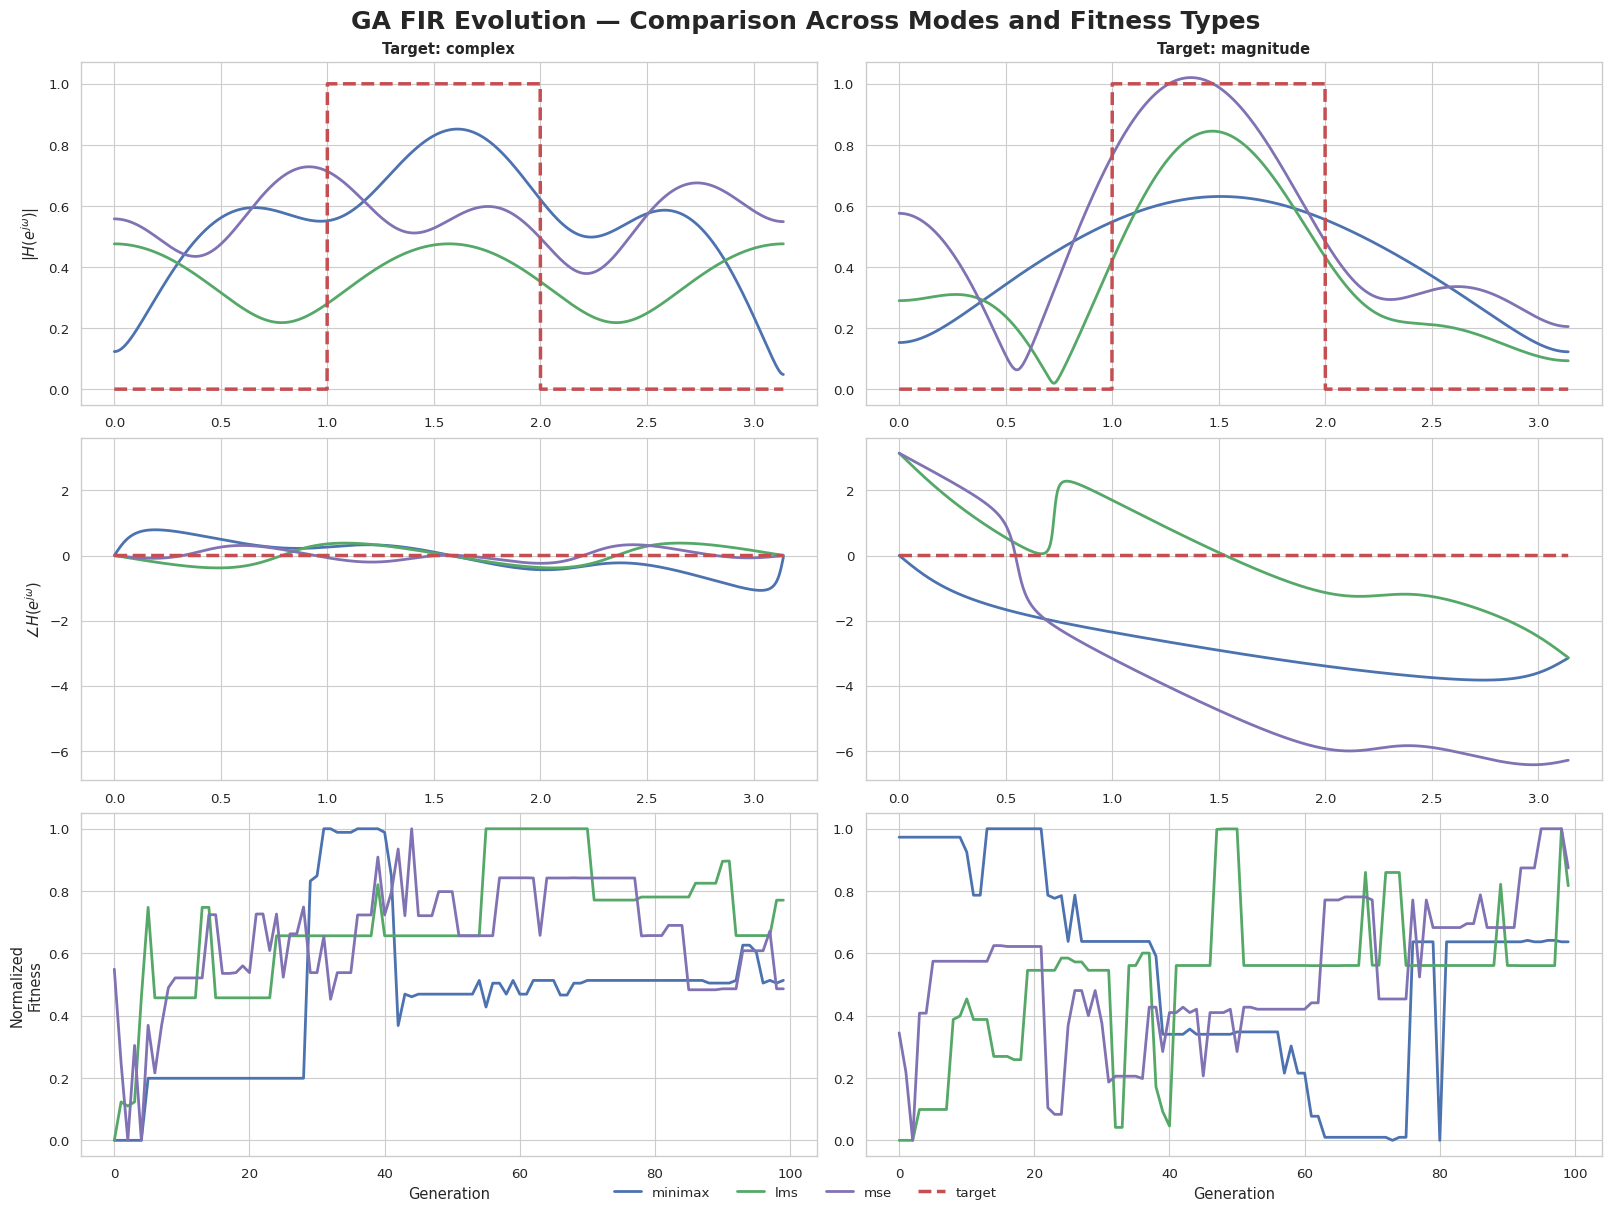

In [90]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]
    b_mse = results[(mode, "mse")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR(b_minimax)
    _, H_lms, _ = compute_FR(b_lms)
    _, H_mse, _ = compute_FR(b_mse)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "mse": np.abs(H_mse),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "mse": np.unwrap(np.angle(H_mse)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit(b, target, mode=mode)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
        "mse": normalize([mse_fit(b, target, mode=mode)
                          for b in results[(mode, "mse")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

#### 3. Ideal differentiator

In [91]:
def target(w):
    return w

In [92]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA(n_pop, generations, order, target, minimax_fit, elitism=False, mode=mode)
    results[(mode, "lms")] = GA(n_pop, generations, order, target, lms_fit, elitism=False, mode=mode)
    results[(mode, "mse")] = GA(n_pop, generations, order, target, mse_fit, elitism=False, mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


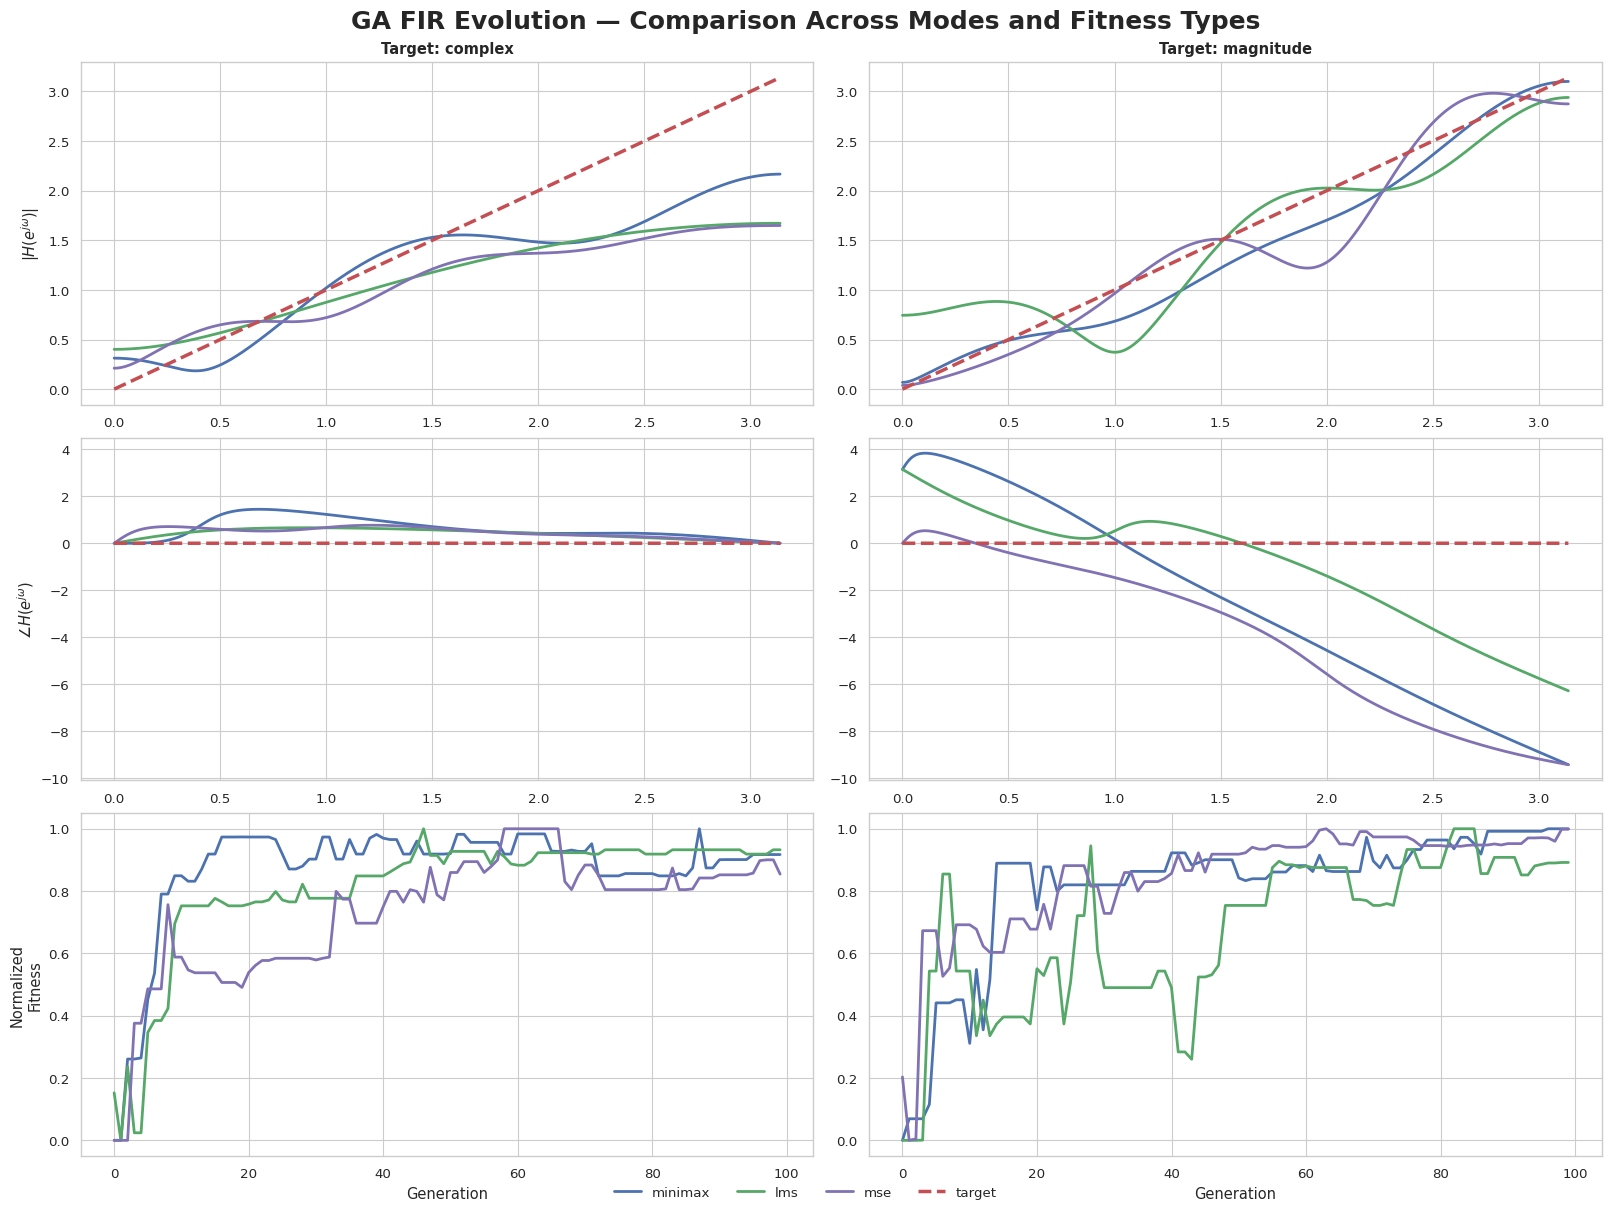

In [93]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]
    b_mse = results[(mode, "mse")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR(b_minimax)
    _, H_lms, _ = compute_FR(b_lms)
    _, H_mse, _ = compute_FR(b_mse)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "mse": np.abs(H_mse),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "mse": np.unwrap(np.angle(H_mse)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit(b, target, mode=mode)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
        "mse": normalize([mse_fit(b, target, mode=mode)
                          for b in results[(mode, "mse")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

#### 4. Ideal Hilbert Transformer

In [94]:
def target(w):
    if w == 0 or w == np.pi:
        return 0.0
    return -1j

#### 5. Ideal Fractional Delay Filter

In [95]:
def target(w, D=0.4):
    return np.exp(-1j * w * D)

#### 6. Ideal Root‑Raised‑Cosine (RRC) Filter

In [96]:
def target(w, alpha=0.25, ws=np.pi):
    w = abs(w)
    if w <= (1 - alpha) * ws / 2:
        return 1.0
    elif (1 - alpha) * ws / 2 < w <= (1 + alpha) * ws / 2:
        return 0.5 * (1 + np.cos(np.pi / (alpha * ws) * (w - (1 - alpha) * ws / 2)))
    else:
        return 0.0

#### 7. Gaussian Low‑Pass Filter

In [97]:
def target(w, sigma=0.5):
    return np.exp(-(sigma ** 2) * (w ** 2) / 2)

#### 8. Derivative of Gaussian (DoG) Filter

In [98]:
def target(w, sigma=0.5):
    return 1j * w * np.exp(-(sigma ** 2) * (w ** 2) / 2)

#### 9. Arbitrary Complex Equalizer

In [99]:
def target(w, G=lambda x: -20 * np.log10(1 + x)):
    mag = 10 ** (G(w) / 20.0)
    return mag

#### 10. Multiband Filter (example: pass–stop–pass)

In [100]:
def target(w, bands=None):
    if bands is None:
        bands = [(0, np.pi / 4), (np.pi / 2, 3 * np.pi / 4)]
    for (a, b) in bands:
        if a <= w <= b:
            return 1.0
    return 0.0

### Observations

As it was expected, computing the fitness over the complex response allows our solutions to get close both to the magnitude and the phase response. If instead we just care about the magnitude, we can reach much better convergence to the desired response, at the price of a completely arbitrary phase. The following papers only care about the latter, but it was interesting to showcase this distinction nonetheless.

## GA using ternary CSD genome

In the first paper we will look at, the objective is to automatically translate a solution to a hardware implementation. In order to minimize the complexity of the circuitry, for each real coefficient of the FIR filter a particular encoding is employed, called CSD. A ternary string is CSD encoded if, given two adjacent digits $d_n, d_{n+1} \in \{-1, 0, 1\}$, $d_n \times d_{n+1} = 0$ and the number of nonzero digits doesn't exceed a provided $d_{max}$.

We remember that a digital FIR filter is characterized by the following transfer function: $H(s)=\sum^{N}_{n=0}a_nz^{-n}$, where $N$ is the order of the filter, and $a_n$ are
defined as the filter coefficients.
Thus, with this encoding, the filter's genome is a list of $N$ ternary strings encoding each of its coefficients, and where the n-th coefficient of the filter is: $a_n=d_0 \times 2^0 + d_1 \times 2^{-1} + ... + d_m \times 2^{-m}$. $m$ is not a fixed number

This encoding is particularly useful because it completely removes the need to handle carry operations, since every nonzero value is always followed by a zero.

### Implementation

Since we already wrote a complete GA for the real-valued case, this change in genome will only require a few modifications.

#### CSD Check
We write a utility function to make sure an individual is CSD-encoded.

In [101]:
def isCSD(individual, d_max):
    for coeff in individual:
        if len(coeff) - coeff.count(0) > d_max: return False
        last_digit = 0
        for digit in coeff:
            if last_digit * digit != 0: return False
            last_digit = digit
    return True

#### Initialization
We can easily generate a random ternary string following the CSD encoding. We need to add a new parameter to make sure to stop before we exceed the maximum number of nonzero digits.

In [168]:
def sample_individual_CSD(order, d_max):
    individual = []
    for _ in range(order):
        coefficient = []
        if random.choice([0, 1]):
            nonzeroes = 0
            last_digit = 0
            while nonzeroes < d_max:
                digit = random.choice([-1, 0, 1])
                if digit * last_digit != 0:
                    digit = 0
                coefficient.append(digit)
                nonzeroes += 1 if digit != 0 else 0
                last_digit = digit
        else:
           coefficient = [0]*random.randint(d_max*2, d_max*4) # If we just create a coefficient with [0] we cannot perform meaningful mutation afterward
        individual.append(coefficient)
    return individual


def init_pop_CSD(order, n_pop, d_max):
    return [sample_individual_CSD(order, d_max) for _ in range(n_pop)]

#### Mutation
Since we are not working in binary, mutation will not be as simple as a bit flip. Thus, flipping a digit will mean choosing between its complementary digits.

In [169]:
def mut_CSD(individual, p=0.01):
    mutated = []
    for coeff in individual:
        mutated_coeff = []
        for digit in coeff:
            if random.random() >= p:
                mut_digit = digit
            else:
                complement = [-1, 0, 1]
                complement.remove(digit)
                mut_digit = random.choice(complement)
            mutated_coeff.append(mut_digit)
        mutated.append(mutated_coeff)
    return mutated

#### Fitness
The fitness calculation remains mostly the same, except we immediately convert through the use of a helper function the ternary coefficients into real numbers. By doing this, we can make use of the previously defined error functions.

In [170]:
def CSD_to_real(coeff):
    real = 0
    for i in range(len(coeff)):
        real += coeff[i] * (2 ** (-i))
    return real


def minimax_fit_CSD(individual, target, mode="complex"):
    return -minimax_error([CSD_to_real(c) for c in individual], target, mode=mode)


def lms_fit_CSD(individual, target, mode="complex"):
    return -lms_error([CSD_to_real(c) for c in individual], target, mode=mode)


def mse_fit_CSD(individual, target, mode="complex"):
    return -mse_error([CSD_to_real(c) for c in individual], target, mode=mode)

#### GA
Due to the addition of the d_max parameter we need to modify our GA function. Furthermore, since we do not perform the mutation in a way that is compatible with CSD, we follow the paper's instructions of checking the CSD validity of every child and retrying mutation until compliant. If the number of retries exceeds $N_{max}$, the child becomes a newly initialized individual.

In [171]:
def GA_CSD(n_pop, generations, order, target, fitness, d_max, N_max, elitism=False, mode="complex"):
    best = []
    elites_n = int(n_pop / 100 * 5) if elitism else 0
    # Population initialization
    pop = init_pop_CSD(order, n_pop, d_max)
    for _ in range(generations):
        pop.sort(key=lambda x: fitness(x, target, mode), reverse=True)
        elites = pop[:elites_n]
        best.append(pop[0])
        for _ in range(n_pop):
            parent1 = pop[random.randint(0, len(pop) - 1)]
            parent2 = pop[random.randint(0, len(pop) - 1)]
            child = mut_CSD(cross(parent1, parent2))
            c = 0
            while not isCSD(child, d_max):
                if c < N_max:
                    child = mut_CSD(cross(parent1, parent2))
                    c += 1
                else:
                    child = sample_individual_CSD(order, d_max)
            pop.append(child)
        pop = selection(pop, n_pop - elites_n, fitness, target, mode)
        pop.extend(elites)
    return best

### Testing basic filters
Before doing any side-by-side comparisons, we will see how the GA behaves on very simple filter designs.

In [172]:
d_max = 3
N_max = 20

In [173]:
def compute_FR_CSD(individual, worN=2048):
    w, H = freqz([CSD_to_real(coeff) for coeff in individual], worN=worN)
    Ht = np.array([target(wi) for wi in w], dtype=complex)
    return w, H, Ht

#### 0. Ideal all-pass filter

In [174]:
def target(w):
    return 1

In [175]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA_CSD(n_pop, generations, order, target, minimax_fit_CSD, d_max, N_max, elitism=False,
                                        mode=mode)
    results[(mode, "lms")] = GA_CSD(n_pop, generations, order, target, lms_fit_CSD, d_max, N_max, elitism=False,
                                    mode=mode)
    results[(mode, "mse")] = GA_CSD(n_pop, generations, order, target, mse_fit_CSD, d_max, N_max, elitism=False,
                                    mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


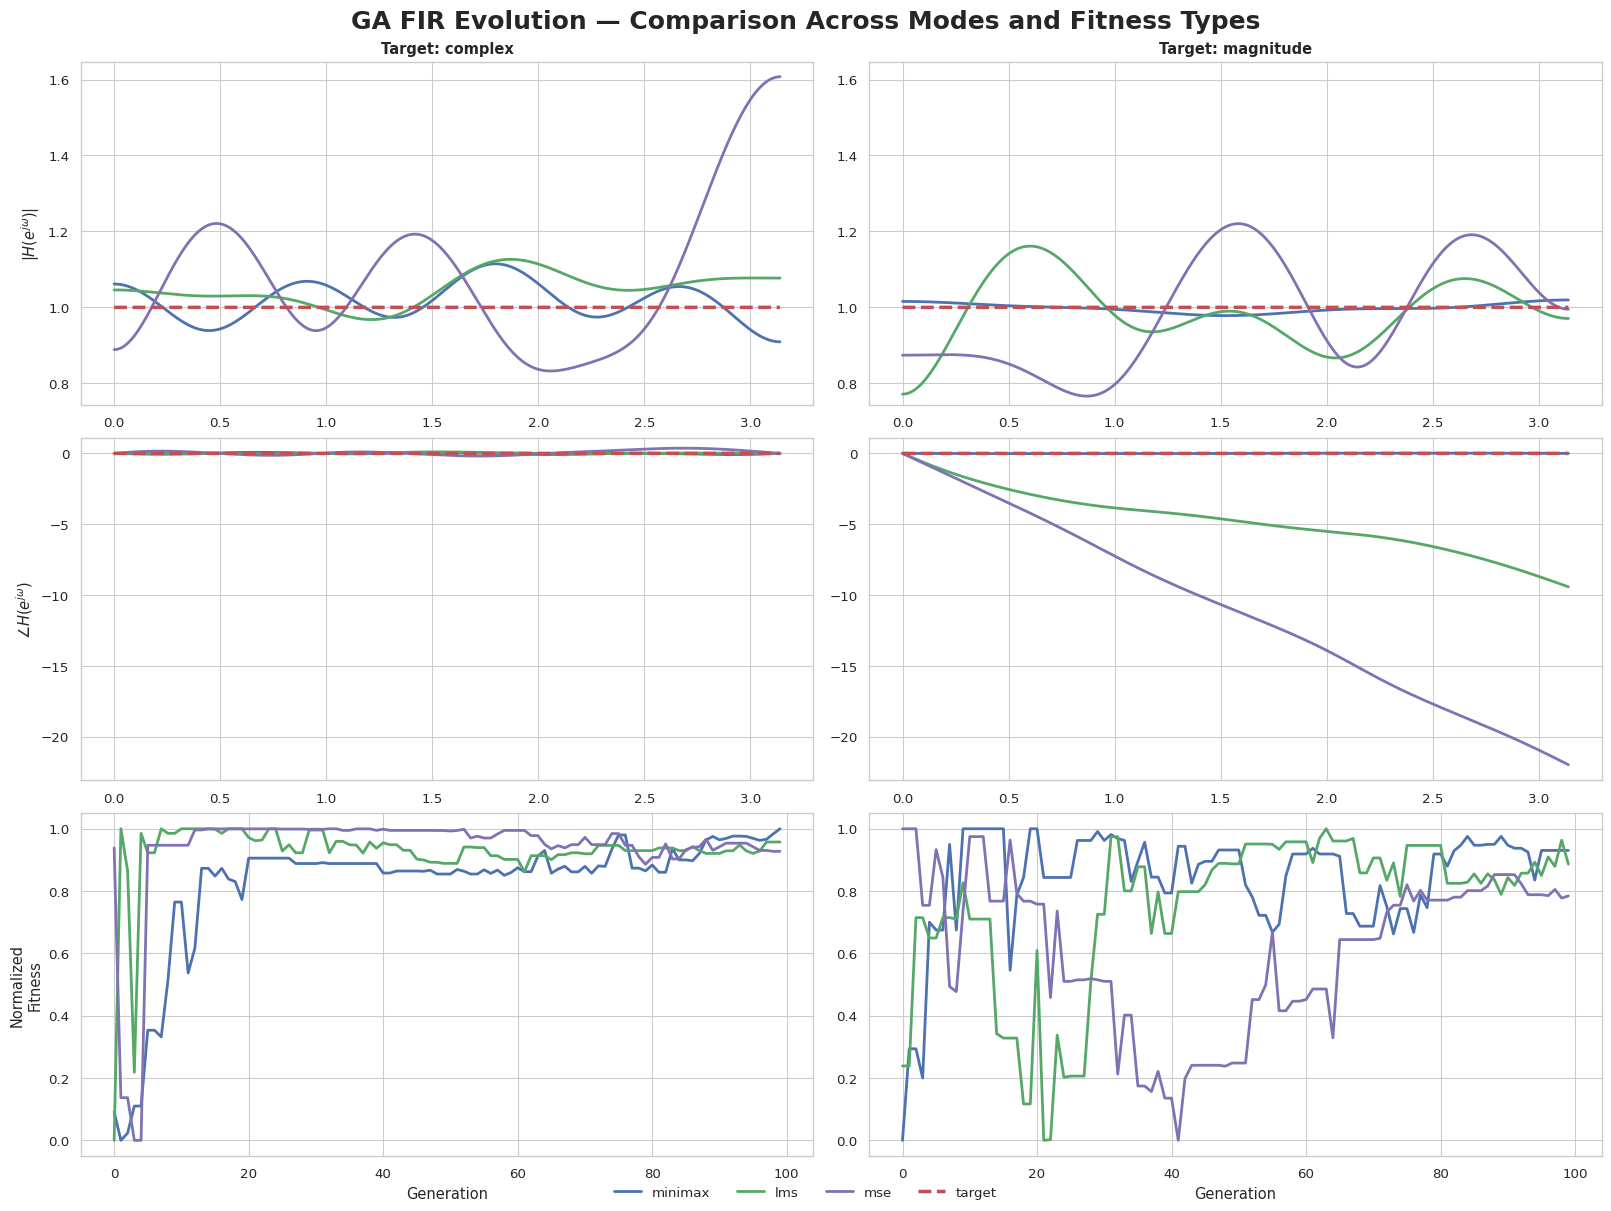

In [176]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]
    b_mse = results[(mode, "mse")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR_CSD(b_minimax)
    _, H_lms, _ = compute_FR_CSD(b_lms)
    _, H_mse, _ = compute_FR_CSD(b_mse)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "mse": np.abs(H_mse),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "mse": np.unwrap(np.angle(H_mse)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit_CSD(b, target, mode=mode)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
        "mse": normalize([mse_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "mse")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

#### 1. Ideal high-pass filter

In [177]:
def target(w):
    return 1 if w >= 1.5 else 0

In [178]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA_CSD(n_pop, generations, order, target, minimax_fit_CSD, d_max, N_max, elitism=False,
                                        mode=mode)
    results[(mode, "lms")] = GA_CSD(n_pop, generations, order, target, lms_fit_CSD, d_max, N_max, elitism=False,
                                    mode=mode)
    results[(mode, "mse")] = GA_CSD(n_pop, generations, order, target, mse_fit_CSD, d_max, N_max, elitism=False,
                                    mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


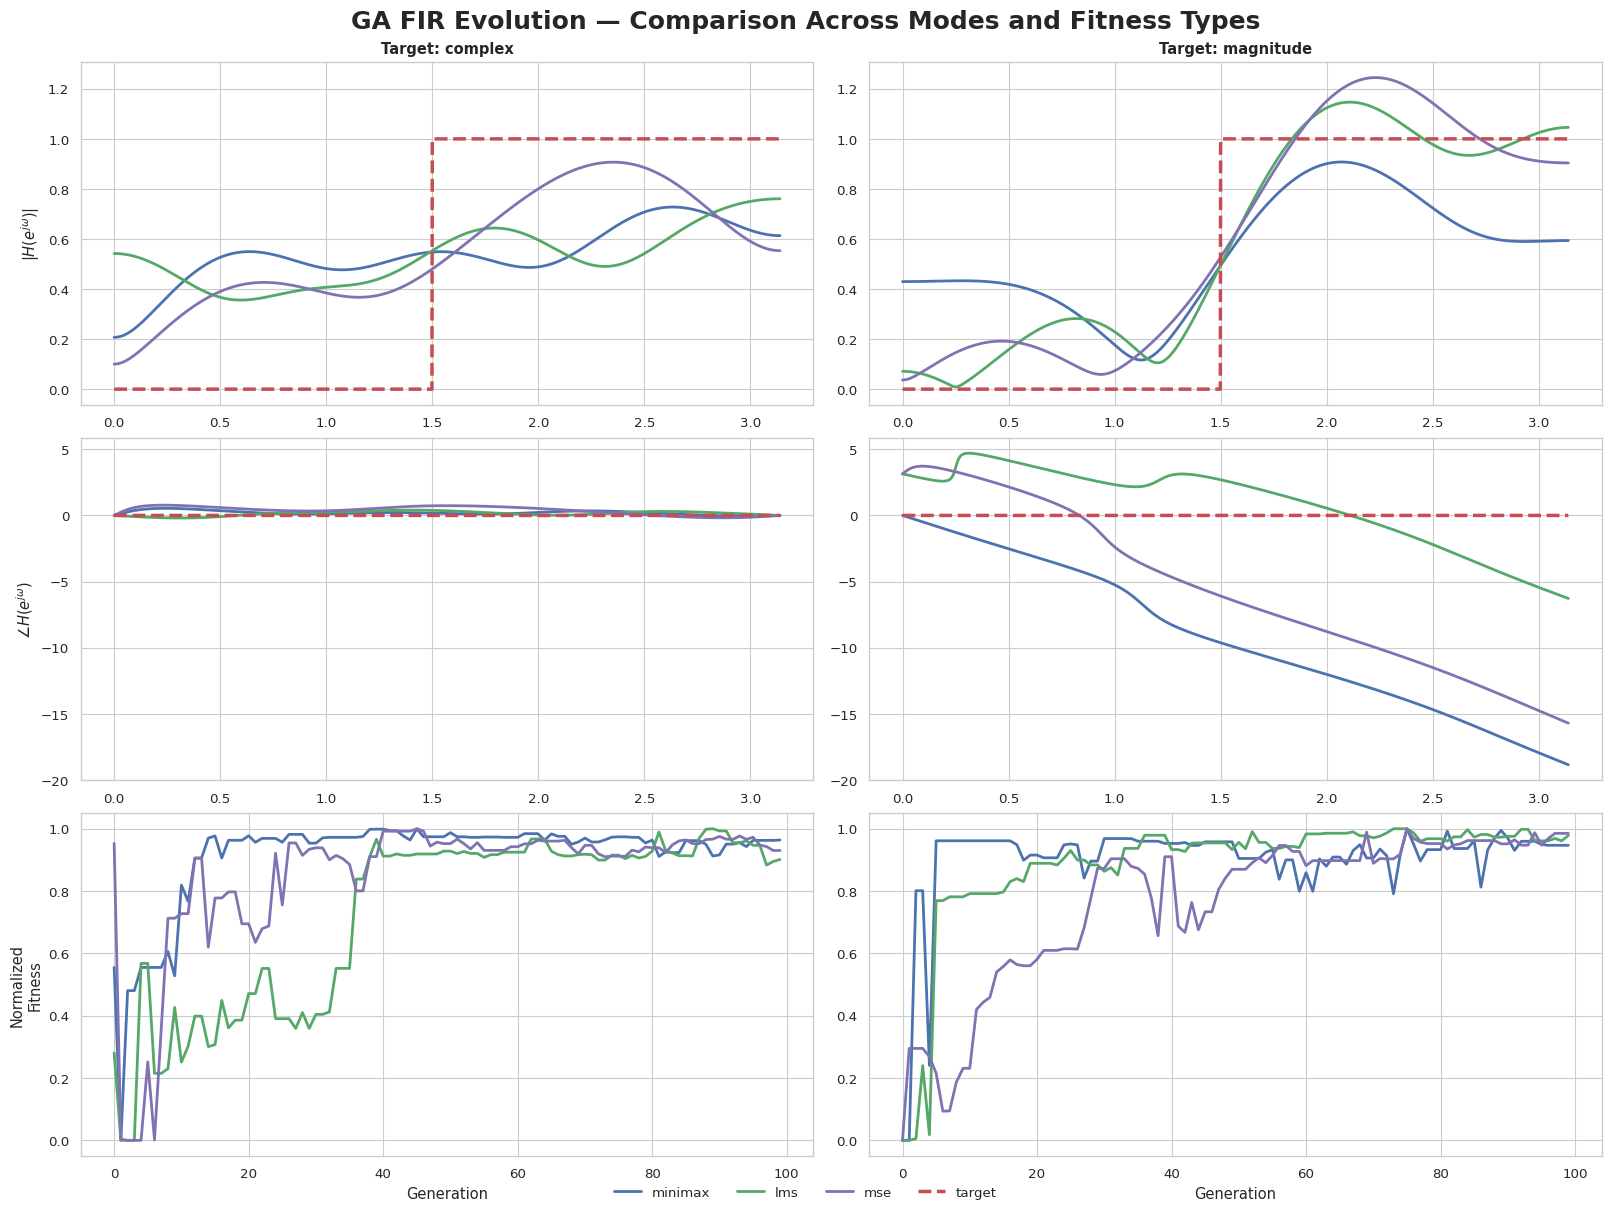

In [179]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]
    b_mse = results[(mode, "mse")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR_CSD(b_minimax)
    _, H_lms, _ = compute_FR_CSD(b_lms)
    _, H_mse, _ = compute_FR_CSD(b_mse)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "mse": np.abs(H_mse),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "mse": np.unwrap(np.angle(H_mse)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit_CSD(b, target, mode=mode)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
        "mse": normalize([mse_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "mse")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

#### 2. Ideal band-pass filter

In [180]:
def target(w):
    return 0 if w >= 2 or w <= 1 else 1

In [181]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA_CSD(n_pop, generations, order, target, minimax_fit_CSD, d_max, N_max, elitism=False,
                                        mode=mode)
    results[(mode, "lms")] = GA_CSD(n_pop, generations, order, target, lms_fit_CSD, d_max, N_max, elitism=False,
                                    mode=mode)
    results[(mode, "mse")] = GA_CSD(n_pop, generations, order, target, mse_fit_CSD, d_max, N_max, elitism=False,
                                    mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


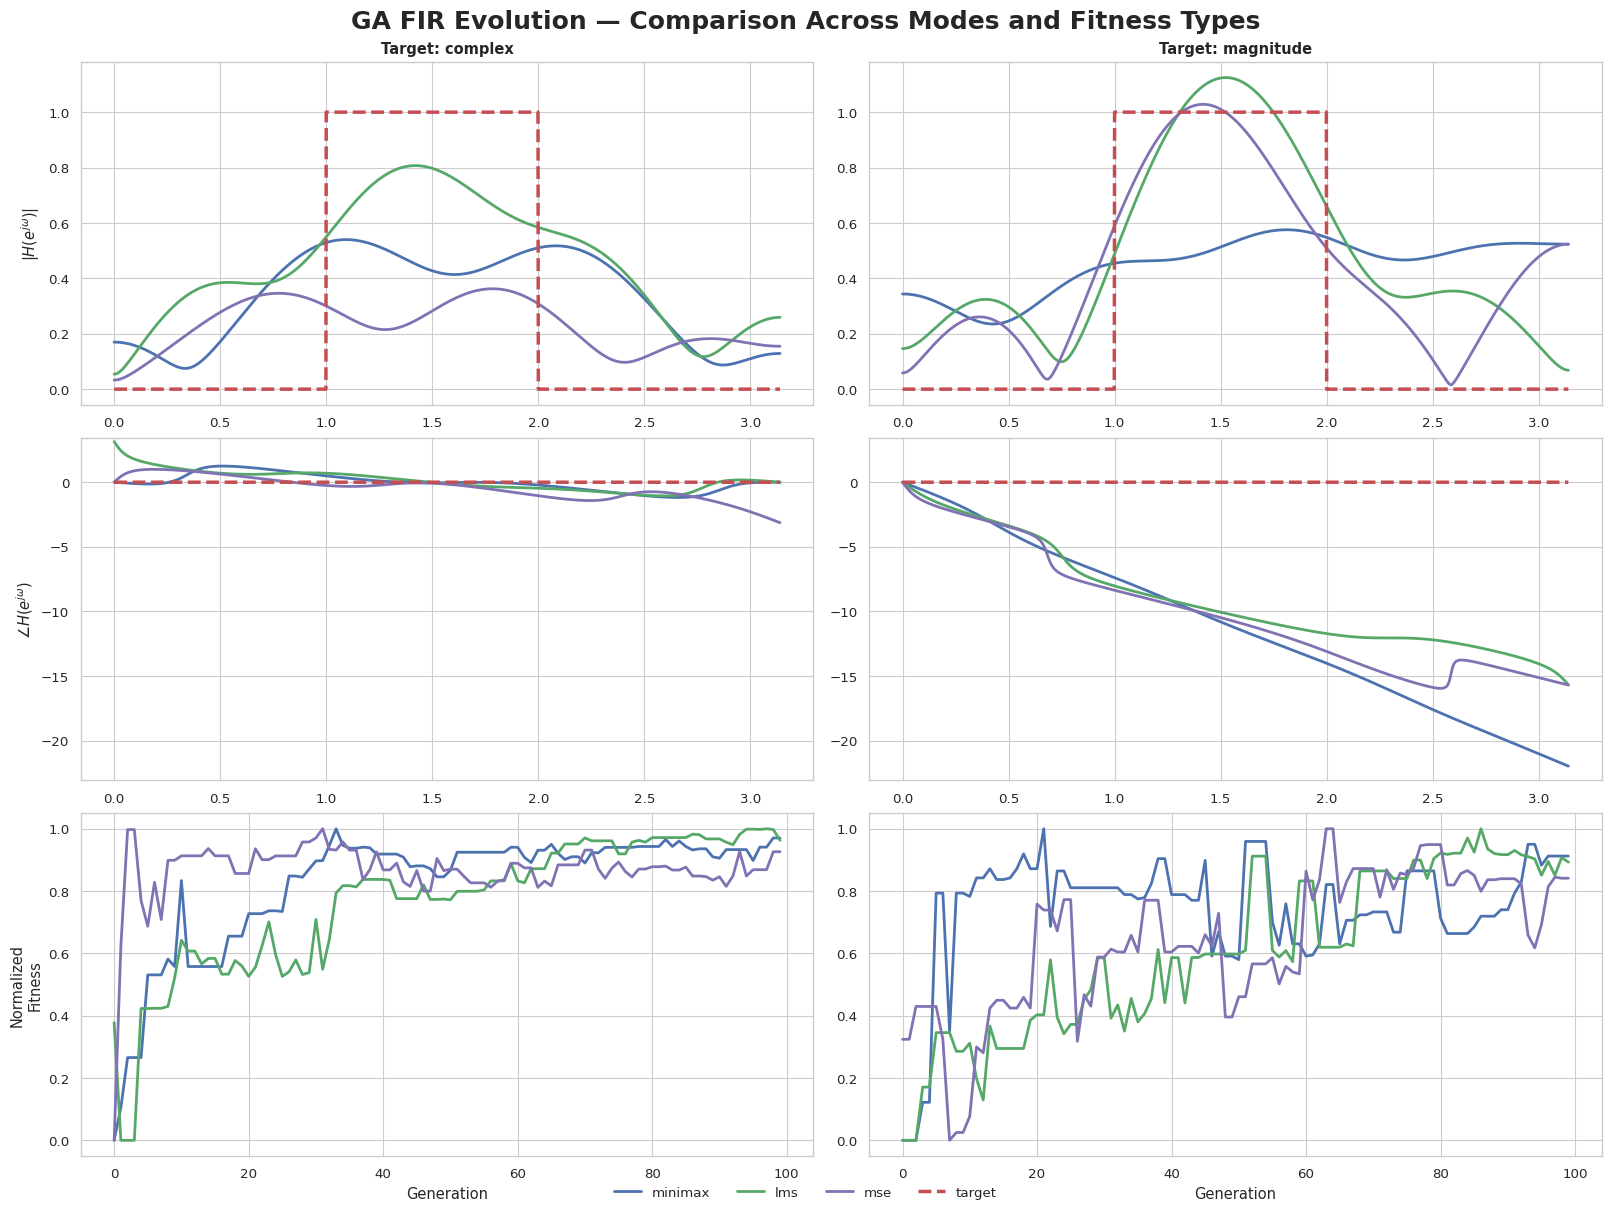

In [182]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]
    b_mse = results[(mode, "mse")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR_CSD(b_minimax)
    _, H_lms, _ = compute_FR_CSD(b_lms)
    _, H_mse, _ = compute_FR_CSD(b_mse)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "mse": np.abs(H_mse),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "mse": np.unwrap(np.angle(H_mse)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit_CSD(b, target, mode=mode)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
        "mse": normalize([mse_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "mse")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

#### 3. Ideal differentiator

In [183]:
def target(w):
    return w

In [184]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA_CSD(n_pop, generations, order, target, minimax_fit_CSD, d_max, N_max, elitism=False,
                                        mode=mode)
    results[(mode, "lms")] = GA_CSD(n_pop, generations, order, target, lms_fit_CSD, d_max, N_max, elitism=False,
                                    mode=mode)
    results[(mode, "mse")] = GA_CSD(n_pop, generations, order, target, mse_fit_CSD, d_max, N_max, elitism=False,
                                    mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


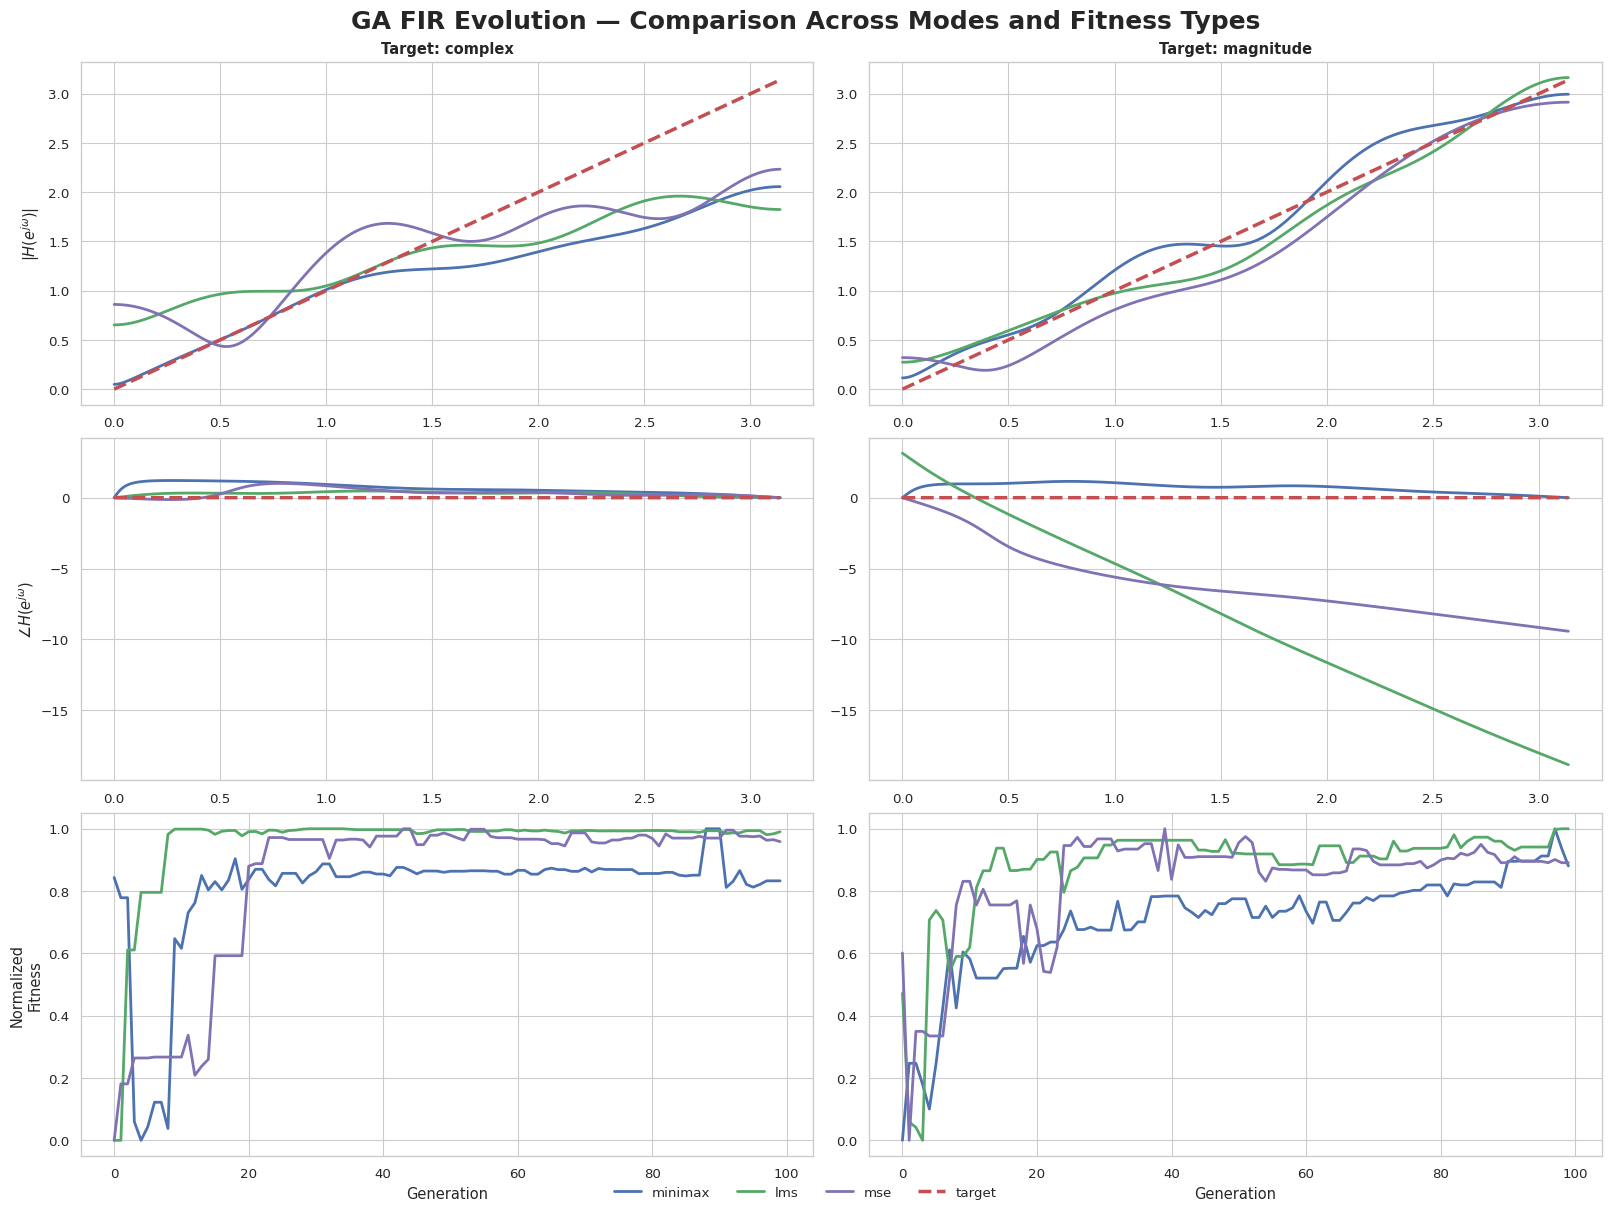

In [185]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]
    b_mse = results[(mode, "mse")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR_CSD(b_minimax)
    _, H_lms, _ = compute_FR_CSD(b_lms)
    _, H_mse, _ = compute_FR_CSD(b_mse)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "mse": np.abs(H_mse),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "mse": np.unwrap(np.angle(H_mse)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit_CSD(b, target, mode=mode)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
        "mse": normalize([mse_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "mse")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

## Improved GA using CSD
The second paper which we will consider, makes some improvement wrt the CSD encoding. In the previous example, we implemented mutation without caring if the procedure was CSD-invariant. This paper proposes a modified mutation and crossover to obtain valid CSD encodings, hopefully making convergence faster.

In [192]:
def mut_CSD2(individual, d_max, p=0.01):
    mutated = []
    for coeff in individual:
        mutated_coeff = []
        last_digit = 0
        nonzeroes = 0
        for digit in coeff:
            if nonzeroes >= d_max:
                break
            if random.random() >= p:
                mut_digit = digit if digit * last_digit == 0 else 0
            else:
                complement = [-1, 0, 1]
                complement.remove(digit)
                mut_digit = random.choice(complement)
                if mut_digit * last_digit != 0:
                    mut_digit = 0
            mutated_coeff.append(mut_digit)
            nonzeroes += 1 if digit != 0 else 0
            last_digit = mut_digit
        mutated.append(mutated_coeff)
    return mutated

In [193]:
def GA_CSD2(n_pop, generations, order, target, fitness, d_max, N_max, elitism=False, mode="complex"):
    best = []
    elites_n = int(n_pop / 100 * 5) if elitism else 0
    # Population initialization
    pop = init_pop_CSD(order, n_pop, d_max)
    for _ in range(generations):
        pop.sort(key=lambda x: fitness(x, target, mode), reverse=True)
        elites = pop[:elites_n]
        best.append(pop[0])
        for _ in range(n_pop):
            parent1 = pop[random.randint(0, len(pop) - 1)]
            parent2 = pop[random.randint(0, len(pop) - 1)]
            child = mut_CSD2(cross(parent1, parent2), d_max)
            pop.append(child)
        pop = selection(pop, n_pop - elites_n, fitness, target, mode)
        pop.extend(elites)
    return best

In [194]:
def target(w):
    return 0 if w >= 2 or w <= 1 else 1

In [195]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA_CSD2(n_pop, generations, order, target, minimax_fit_CSD, d_max, N_max, elitism=False,
                                        mode=mode)
    results[(mode, "lms")] = GA_CSD2(n_pop, generations, order, target, lms_fit_CSD, d_max, N_max, elitism=False,
                                    mode=mode)
    results[(mode, "mse")] = GA_CSD2(n_pop, generations, order, target, mse_fit_CSD, d_max, N_max, elitism=False,
                                    mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


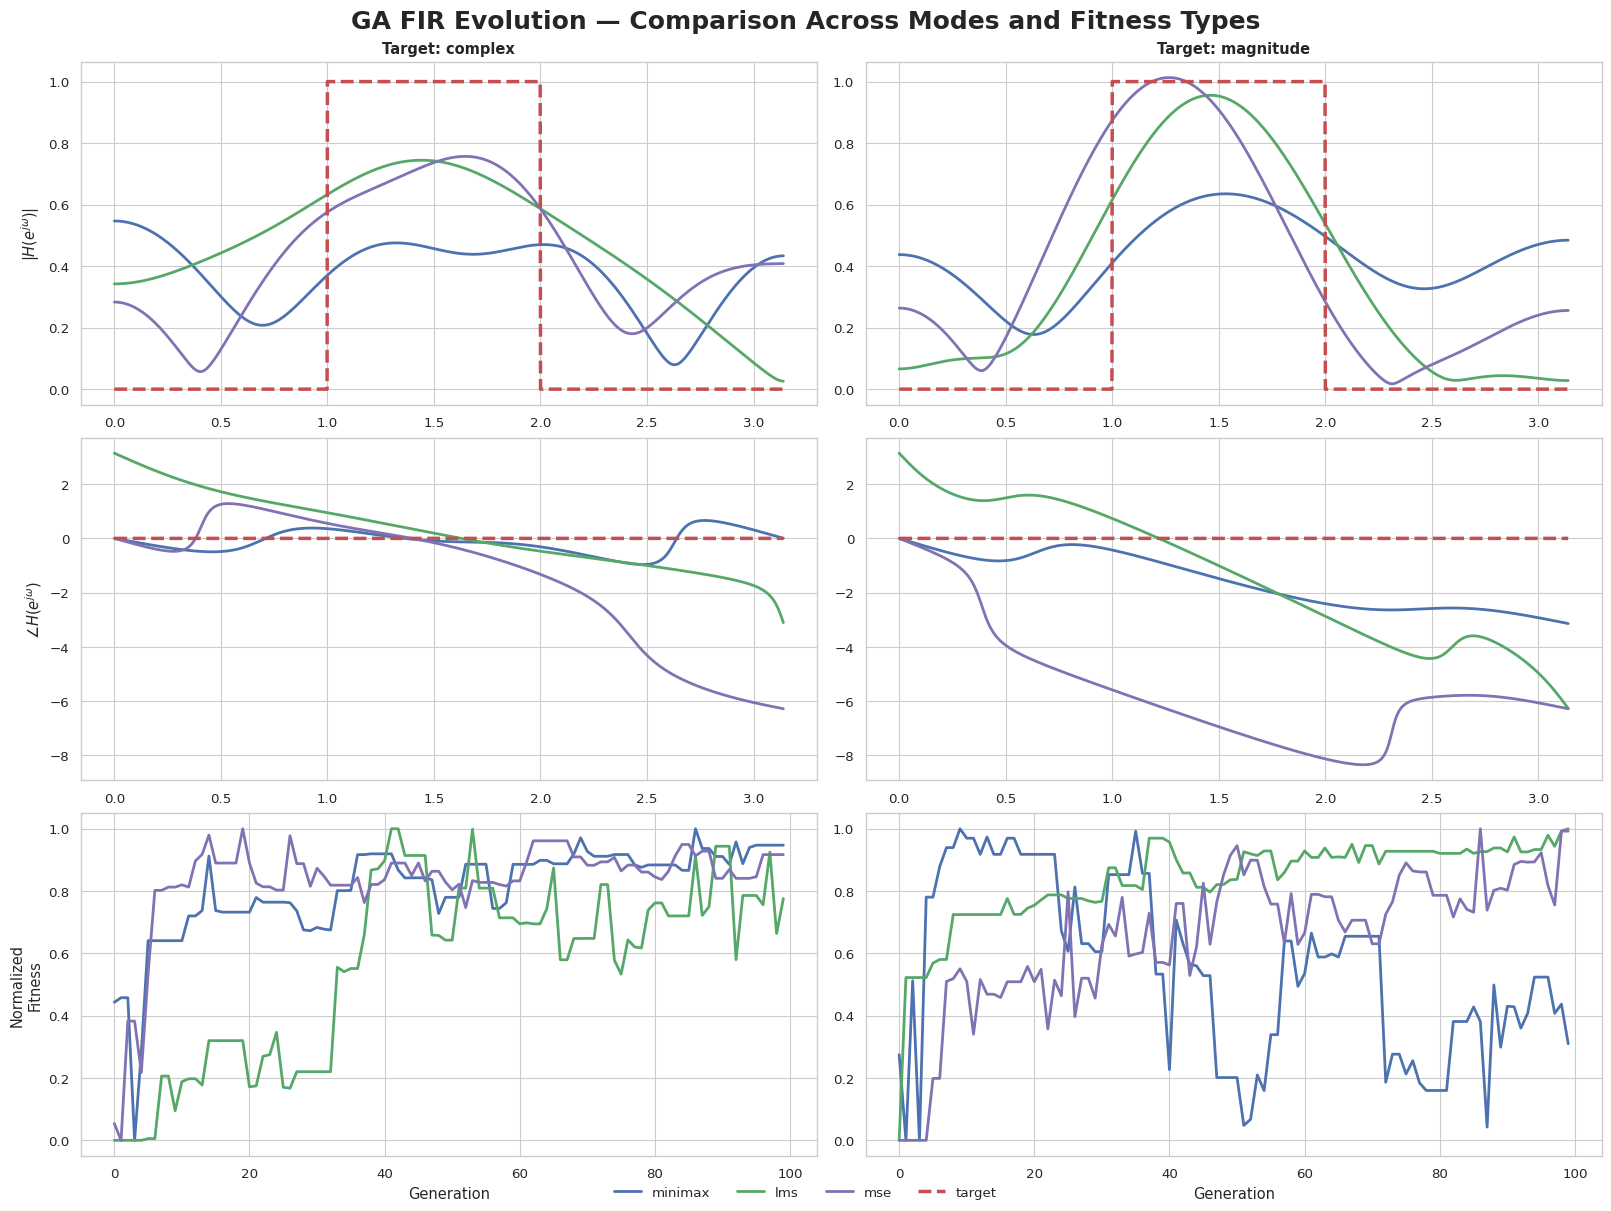

In [196]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]
    b_mse = results[(mode, "mse")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR_CSD(b_minimax)
    _, H_lms, _ = compute_FR_CSD(b_lms)
    _, H_mse, _ = compute_FR_CSD(b_mse)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "mse": np.abs(H_mse),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "mse": np.unwrap(np.angle(H_mse)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit_CSD(b, target, mode=mode)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
        "mse": normalize([mse_fit_CSD(b, target, mode=mode)
                          for b in results[(mode, "mse")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms", "mse"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()